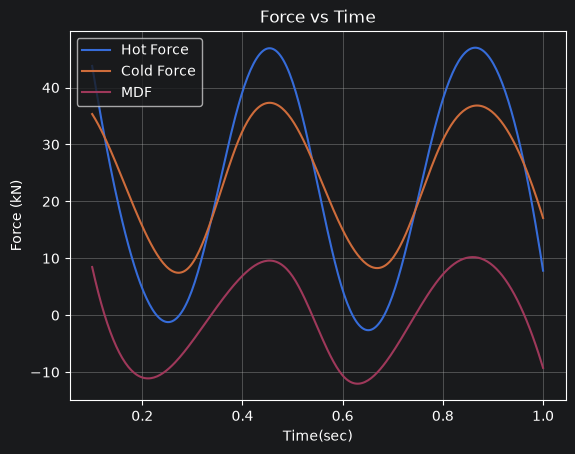

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Read data from Excel file
data = pd.read_excel("MDF.xlsx")

#Remove empty rows or missing values
data = data.dropna()

#Read columns from Excel
time = data["Time(sec)"]
hot_force = data["Ft(hot) (kN)"]
cold_force = data["Ft(cold) (kN)"]
mdf = data["MDF(kN)"]

#Create smooth time points
time_smooth = np.linspace(time.min(), time.max(), 300)

#Smooth curves
hot_smooth = make_interp_spline(time, hot_force)(time_smooth)
cold_smooth = make_interp_spline(time, cold_force)(time_smooth)
mdf_smooth = make_interp_spline(time, mdf)(time_smooth)

#Plotting
plt.plot(time_smooth, hot_smooth, label="Hot Force")
plt.plot(time_smooth, cold_smooth, label="Cold Force")
plt.plot(time_smooth, mdf_smooth, label="MDF")

plt.xlabel("Time(sec)")
plt.ylabel("Force (kN)")
plt.title("Force vs Time")
plt.legend()
plt.grid(True)

#plt.savefig("MDF_graph.png", dpi=300, bbox_inches="tight")
plt.show()